In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max.rows',130)
pd.set_option('display.max.columns',130)
pd.set_option('float_format', '{:.2f}'.format)

In [2]:
df = pd.read_csv(r"C:\Users\user\Downloads\application_data.csv.zip")

ДЗ 1. Аналіз стовпців AMT_REQ_CREDIT_BUREAU з пропущеними значеннями
Виведіть середнє, моду, медіану та відсоток відсутніх даних для настуних колонок:

AMT_REQ_CREDIT_BUREAU_YEAR
AMT_REQ_CREDIT_BUREAU_MON
AMT_REQ_CREDIT_BUREAU_WEEK
На основі виведених даних напишіть висновок про те, чи варто заповнювати пусті значення і якщо так, то яким чином?

In [5]:
amts = ['AMT_REQ_CREDIT_BUREAU_YEAR', 'AMT_REQ_CREDIT_BUREAU_MON', 'AMT_REQ_CREDIT_BUREAU_WEEK']
for amt in amts:
    print (f'{amt}')
    print (f'Mean: {df[amt].mean():.2f}')
    print (f'Mode: {df[amt].mode()[0]:.2f}')
    print (f'Median: {df[amt].median():.2f}')
    print (f'Missing: {df[amt].isnull().mean()*100:.2f}%')
 

AMT_REQ_CREDIT_BUREAU_YEAR
Mean: 1.90
Mode: 0.00
Median: 1.00
Missing: 13.50%
AMT_REQ_CREDIT_BUREAU_MON
Mean: 0.27
Mode: 0.00
Median: 0.00
Missing: 13.50%
AMT_REQ_CREDIT_BUREAU_WEEK
Mean: 0.03
Mode: 0.00
Median: 0.00
Missing: 13.50%


ДЗ 2. Аналіз і заповнення пустих значень у колонках з малим відсотком пропущених
За прикладом вище проведіть аналіз пропущених значень в колонках

EXT_SOURCE_2
AMT_GOODS_PRICE
Для швидшого аналізу рекомендую написати фукнцію, яку Ви зможете викликати для кожної з колонок.

Зробіть висновок, що робити з пропущеними значеннями в кожному випадку і виконанайте ту дію, яку зазначили.


In [20]:
def analyze_column(amt):
    print(f"{amt}")
    print(f"Mean:    {df[amt].mean():.2f}")
    print(f"Median:  {df[amt].median():.2f}")
    print(f"Mode:    {df[amt].mode()[0]:.2f}")
    print(f'Missing: {df[amt].isnull().mean()*100:.2f}%')
analyze_column('EXT_SOURCE_2')
analyze_column('AMT_GOODS_PRICE')

EXT_SOURCE_2
Mean:    0.51
Median:  0.57
Mode:    0.29
Missing: 0.21%
AMT_GOODS_PRICE
Mean:    538396.21
Median:  450000.00
Mode:    450000.00
Missing: 0.09%


ДЗ 3. Аналіз викидів
Подібно до прикладу, проаналізуйте на викиди колонок

CNT_FAM_MEMBERS
AMT_ANNUITY
Зазначте, які значення в них можна вважати викидами.

In [39]:
def analyze_outliners (amt):
    print(f'{amt}')
    Q1=df[amt].quantile(0.25)
    Q3=df[amt].quantile(0.75)
    IQR=Q3-Q1
    lower=Q1-1.5*IQR
    upper=Q3+1.5*IQR
    print("Мінімальне значення, до якого існують викиди: {}".format(lower))
    print("Максимальне значення, після якого існують викиди: {}".format(upper))
analyze_outliners('CNT_FAM_MEMBERS')
analyze_outliners('AMT_ANNUITY')

CNT_FAM_MEMBERS
Мінімальне значення, до якого існують викиди: 0.5
Максимальне значення, після якого існують викиди: 4.5
AMT_ANNUITY
Мінімальне значення, до якого існують викиди: -10584.0
Максимальне значення, після якого існують викиди: 61704.0


ДЗ 4. Одновимірний аналіз категоріальної колонки
За наведеним прикладом вище, проведіть аналіз залежності між категоріальною колонкою і цільовою для колонок

CODE_GENDER
FLAG_OWN_CAR
Опціонально (для тих, кому цікаво дослідити більше даних)

NAME_INCOME_TYPE
NAME_EDUCATION_TYPE
NAME_FAMILY_STATUS
Чи є вплив цих змінних на цільову та який саме?

In [57]:
def analyze_category (amt):
    print(f'{amt}')
    print(df[amt].value_counts())
    print ()
    print(df.groupby(amt)['TARGET'].mean() * 100)
    print ()
analyze_category('CODE_GENDER')
analyze_category('FLAG_OWN_CAR')


CODE_GENDER
CODE_GENDER
F      202448
M      105059
XNA         4
Name: count, dtype: int64

CODE_GENDER
F      7.00
M     10.14
XNA    0.00
Name: TARGET, dtype: float64

FLAG_OWN_CAR
FLAG_OWN_CAR
N    202924
Y    104587
Name: count, dtype: int64

FLAG_OWN_CAR
N   8.50
Y   7.24
Name: TARGET, dtype: float64



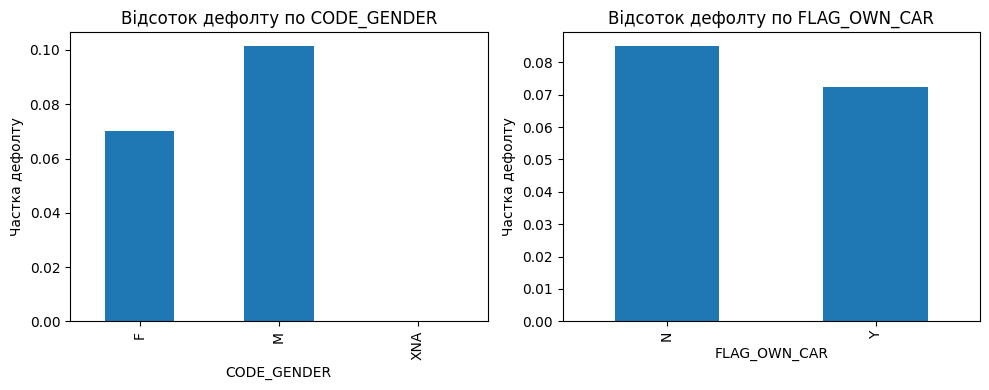

In [81]:
code, flag = plt.subplots(1, 2, figsize=(10, 4))

for i, col in enumerate(['CODE_GENDER', 'FLAG_OWN_CAR']):
    df.groupby(col)['TARGET'].mean().plot(kind='bar', ax=flag[i])
    flag[i].set_title(f'Відсоток дефолту по {col}')
    flag[i].set_ylabel('Частка дефолту')
    flag[i].set_xlabel(col) 

plt.tight_layout()
plt.show()

ДЗ 5. Одновимірний аналіз числової колонки
За наведеним вище прикладом, проведіть одновимірний аналіз (виявлення викидів, їх усунення та побудова KDE  графіку) для числових змінних

YEARS_BIRTH
AMT_GOODS_PRICE
DAYS_EMPLOYED
Опціонально:

CNT_CHILDREN
AMT_INCOME_TOTAL
Для цього винесіть функціонал для аналізу у функцію та викличіть функцію для кожної двійки змінних.

Зробіть висновки з аналізу.

YEARS_BIRTH
Mean:    43.44
Median:  43.00
Mode:    38.00
Missing: 0.00%
Мінімальне значення, до якого існують викиди: 5.50
Максимальне значення, після якого існують викиди: 81.50
Кількість викидів: 0 (0.0%)
Розмір після очищення: 307511 (до очищення: 307511)


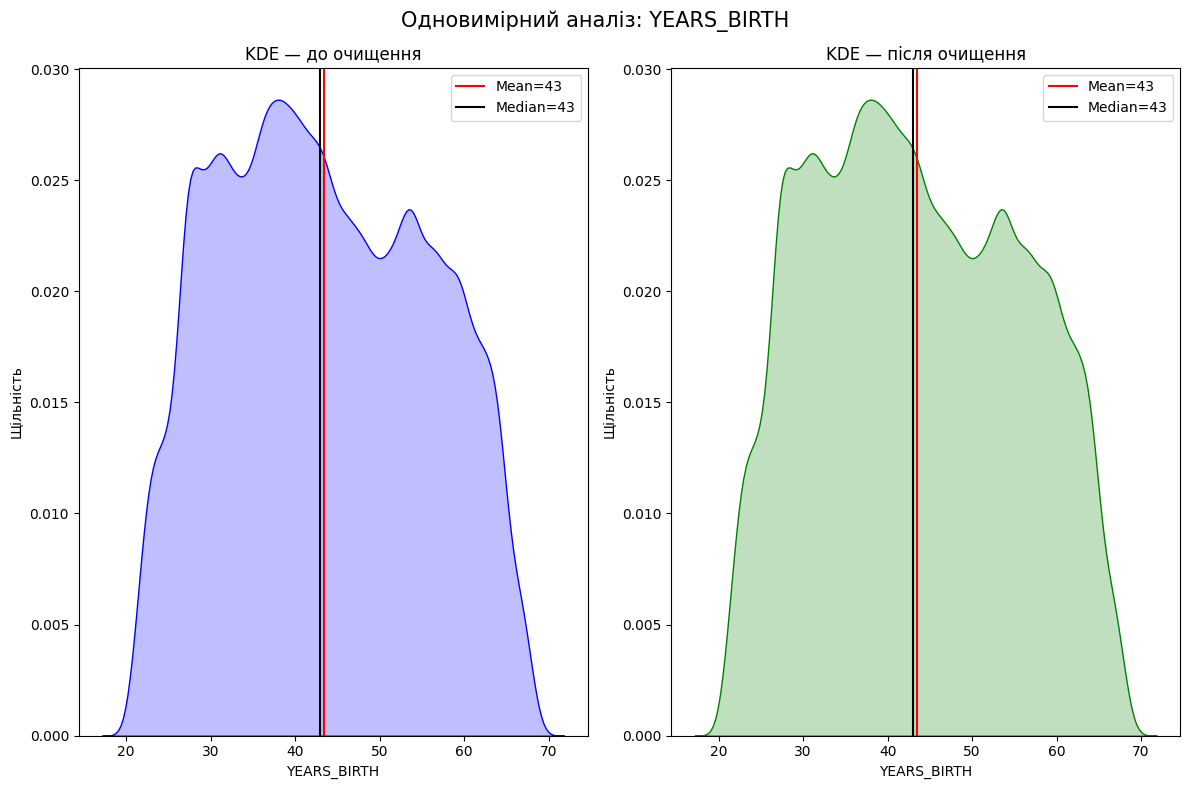

AMT_GOODS_PRICE
Mean:    538396.21
Median:  450000.00
Mode:    450000.00
Missing: 0.09%
Мінімальне значення, до якого існують викиди: -423000.00
Максимальне значення, після якого існують викиди: 1341000.00
Кількість викидів: 14728 (4.8%)
Розмір після очищення: 292505 (до очищення: 307233)


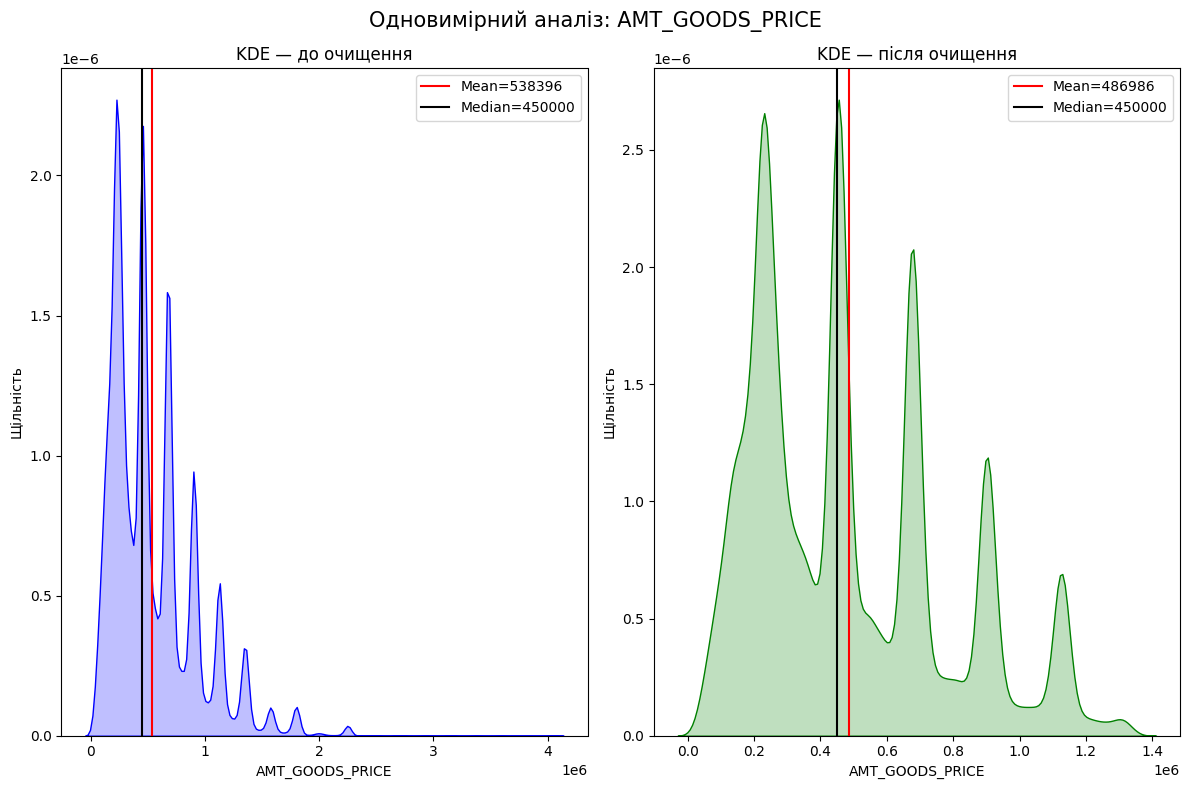

In [42]:
def analyze_numeric(col_name):
    series = df[col_name].dropna()
    
    print(f'{col_name}')
    print(f'Mean:    {df[col_name].mean():.2f}')
    print(f'Median:  {df[col_name].median():.2f}')
    print(f'Mode:    {df[col_name].mode()[0]:.2f}')
    print(f'Missing: {df[col_name].isnull().mean()*100:.2f}%')

    Q1    = series.quantile(0.25)
    Q3    = series.quantile(0.75)
    IQR   = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    outliers     = series[(series < lower) | (series > upper)]
    series_clean = series[(series >= lower) & (series <= upper)]
    
    print(f'Мінімальне значення, до якого існують викиди: {lower:.2f}')
    print(f'Максимальне значення, після якого існують викиди: {upper:.2f}')
    print(f'Кількість викидів: {len(outliers)} ({len(outliers)/len(series)*100:.1f}%)')
    print(f'Розмір після очищення: {len(series_clean)} (до очищення: {len(series)})')

    fig, axes = plt.subplots(1, 2, figsize=(12, 8))
    fig.suptitle(f'Одновимірний аналіз: {col_name}', fontsize=15)

    sns.kdeplot(series, ax=axes[0], fill=True, color='blue')
    axes[0].axvline(series.mean(),   color='red', label=f'Mean={series.mean():.0f}')
    axes[0].axvline(series.median(), color='black', label=f'Median={series.median():.0f}')
    axes[0].set_title('KDE — до очищення')
    axes[0].set_xlabel(col_name)
    axes[0].set_ylabel('Щільність')
    axes[0].legend(fontsize=10)

    sns.kdeplot(series_clean, ax=axes[1], fill=True, color='green')
    axes[1].axvline(series_clean.mean(),   color='red', label=f'Mean={series_clean.mean():.0f}')
    axes[1].axvline(series_clean.median(), color='black', label=f'Median={series_clean.median():.0f}')
    axes[1].set_title('KDE — після очищення')
    axes[1].set_xlabel(col_name)
    axes[1].set_ylabel('Щільність')
    axes[1].legend(fontsize=10)

    plt.tight_layout()
    plt.show()

df['YEARS_BIRTH'] = (df['DAYS_BIRTH'] / -365).astype(int)

analyze_numeric('YEARS_BIRTH')
analyze_numeric('AMT_GOODS_PRICE')

Висновки:
YEARS_BIRTH
- викидів немає
- графіки ідентичні до і після
- медіана і середнє практично однаковий, без скосу
AMT_GOODS_PRICE
- Викидів 4.8%
- нижня межа IQR з мінусом, це означає що всі викиди тільки  зверху
- правосторонній скос, аномальні значення сильно впливають на середнє

ДЗ 6. Кореляційний аналіз для пари числових змінних
За наведеним вище прикладом, проведіть кореляційний аналіз для пар змінних

AMT_ANNUITY і AMT_CREDIT
Опціонально:

DAYS_EMPLOYED і AMT_INCOME_TOTAL
AMT_CREDIT і DAYS_BIRTH
Для цього винесіть функціонал для аналізу у функцію та викличіть функцію для кожної двійки змінних. Зробіть висновок про наявність кореляції між змінними.

AMT_ANNUITY і AMT_CREDIT
Pearson:  0.77
Spearman: 0.83


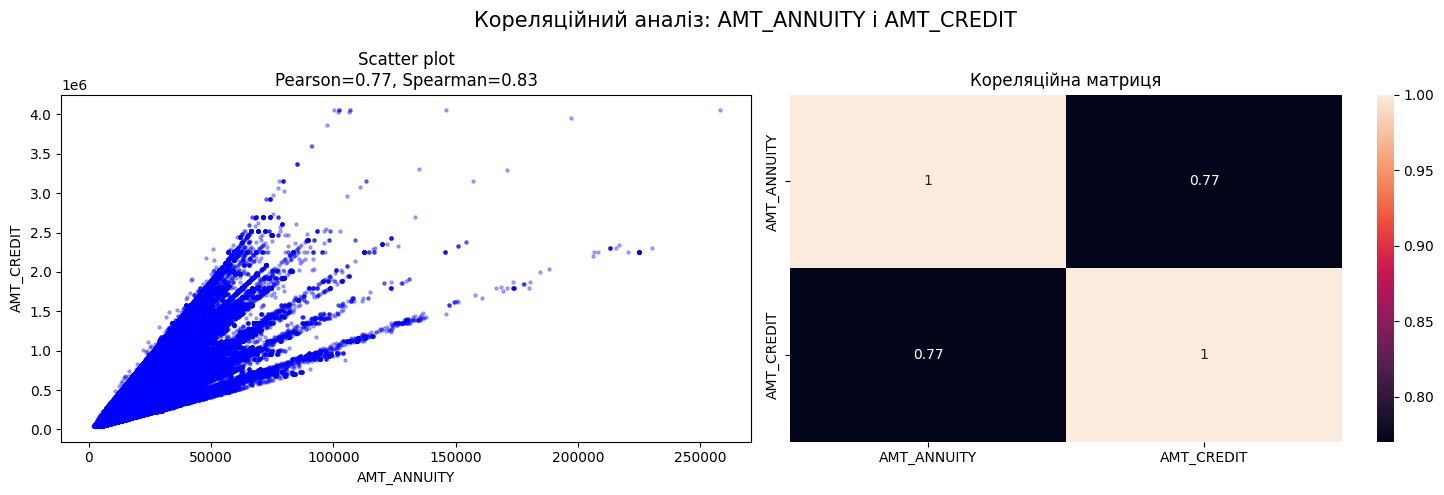

In [74]:
def analyze_correlation(col1, col2):
    data = df[[col1, col2]].dropna()
    
    pearson  = data[col1].corr(data[col2])
    spearman = data[col1].rank().corr(data[col2].rank())
    
    print(f'{col1} і {col2}')
    print(f'Pearson:  {pearson:.2f}')
    print(f'Spearman: {spearman:.2f}')
    
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'Кореляційний аналіз: {col1} і {col2}', fontsize=15)
    
    axes[0].scatter(data[col1], data[col2], alpha=0.3, s=5, color='blue')
    axes[0].set_xlabel(col1)
    axes[0].set_ylabel(col2)
    axes[0].set_title(f'Scatter plot\nPearson={pearson:.2f}, Spearman={spearman:.2f}')
    
    sns.heatmap(data[[col1, col2]].corr(), ax=axes[1],annot=True)
    axes[1].set_title('Кореляційна матриця')
    
    plt.tight_layout()
    plt.show()

analyze_correlation('AMT_ANNUITY', 'AMT_CREDIT')

Висновки:
- Сильна лінійна кореляція
- показники Pearson та Spearam практично однакові, а це означає що звязок між ними прямолінійний і дані не мають викидів

AMT_INCOME_TOTAL vs NAME_FAMILY_STATUS vs CODE_GENDER
Середнє по NAME_FAMILY_STATUS:
NAME_FAMILY_STATUS
Civil marriage         167840.53
Married                171012.35
Separated              171231.79
Single / not married   167919.87
Unknown                326250.00
Widow                  143001.65
Name: AMT_INCOME_TOTAL, dtype: float64
Середнє по CODE_GENDER:
CODE_GENDER
F     156032.31
M     193396.48
XNA   186750.00
Name: AMT_INCOME_TOTAL, dtype: float64


C:\Users\user\AppData\Local\Temp\ipykernel_23128\643556697.py:27: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[2].legend(title=cat_col2)


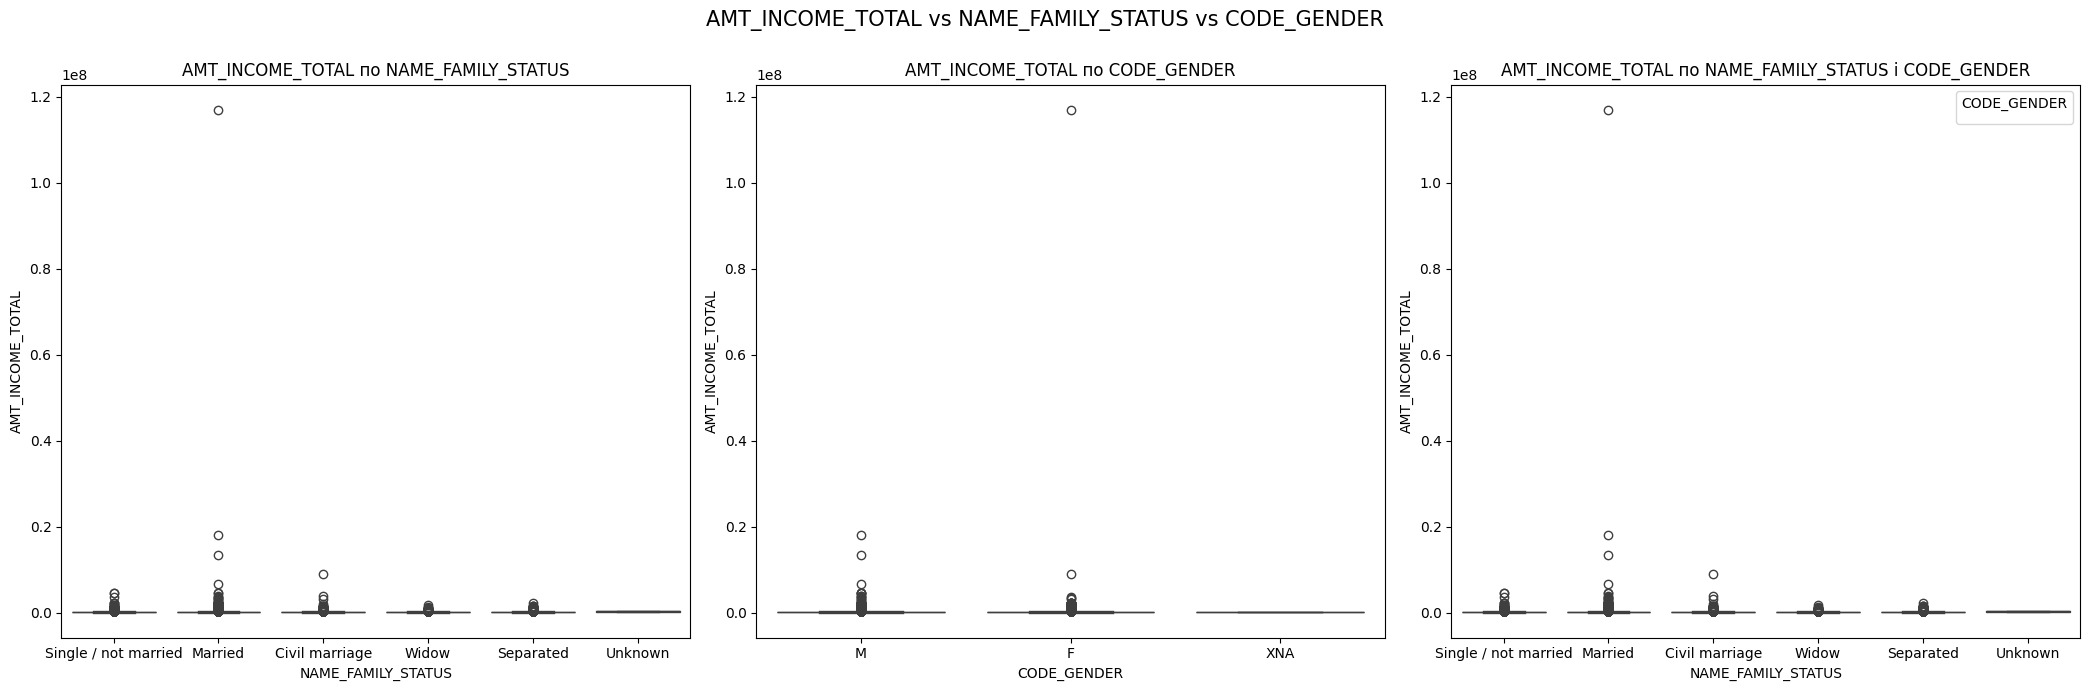

In [77]:
def analyze_cat_correlation(num_col, cat_col1, cat_col2):
    data = df[[num_col, cat_col1, cat_col2]].dropna()

    print(f'{num_col} vs {cat_col1} vs {cat_col2}')
    print(f'Середнє по {cat_col1}:')
    print(data.groupby(cat_col1)[num_col].mean().round(2))
    print(f'Середнє по {cat_col2}:')
    print(data.groupby(cat_col2)[num_col].mean().round(2))

    fig, axes = plt.subplots(1, 3, figsize=(21, 7))
    fig.suptitle(f'{num_col} vs {cat_col1} vs {cat_col2}', fontsize=15)

    sns.boxplot(data=data, x=cat_col1, y=num_col, ax=axes[0])
    axes[0].set_title(f'{num_col} по {cat_col1}')
    axes[0].set_xlabel(cat_col1)
    axes[0].set_ylabel(num_col)

    sns.boxplot(data=data, x=cat_col2, y=num_col, ax=axes[1])
    axes[1].set_title(f'{num_col} по {cat_col2}')
    axes[1].set_xlabel(cat_col2)
    axes[1].set_ylabel(num_col)

    sns.boxplot(data=data, x=cat_col1, y=num_col, ax=axes[2])
    axes[2].set_title(f'{num_col} по {cat_col1} і {cat_col2}')
    axes[2].set_xlabel(cat_col1)
    axes[2].set_ylabel(num_col)
    axes[2].legend(title=cat_col2)

    plt.tight_layout()
    plt.show()

analyze_cat_correlation('AMT_INCOME_TOTAL', 'NAME_FAMILY_STATUS', 'CODE_GENDER')

Висновки:
- Одружені клієнти мають вищий середній дохід
- Чоловіки мають вищий середній дохід
- в 3 колонки різниця між статтями не впливають на дохід


ДЗ 8. Аналіз взаємозалежностей між двома категоріальними змінними
Проведіть подібний до прикладу аналіз залежностей між категоріальними змінними для пар змінних

NAME_EDUCATION_TYPE vs CODE_GENDER
Опціонально:

NAME_FAMILY_STATUS vs OCCUPATION_TYPE
OCCUPATION_TYPE vs NAME_CONTRACT_TYPE
Опишіть спостереження щодо того, чи є цікаві знахідки стосовно цільової змінної з цього аналізу.

NAME_EDUCATION_TYPE vs CODE_GENDER
NAME_EDUCATION_TYPE            CODE_GENDER
Academic degree                F              3.00
                               M              0.00
Higher education               F              4.85
                               M              6.39
                               XNA            0.00
Incomplete higher              F              8.02
                               M              9.22
                               XNA            0.00
Lower secondary                F              9.26
                               M             13.49
Secondary / secondary special  F              7.68
                               M             11.36
                               XNA            0.00
Name: TARGET, dtype: float64


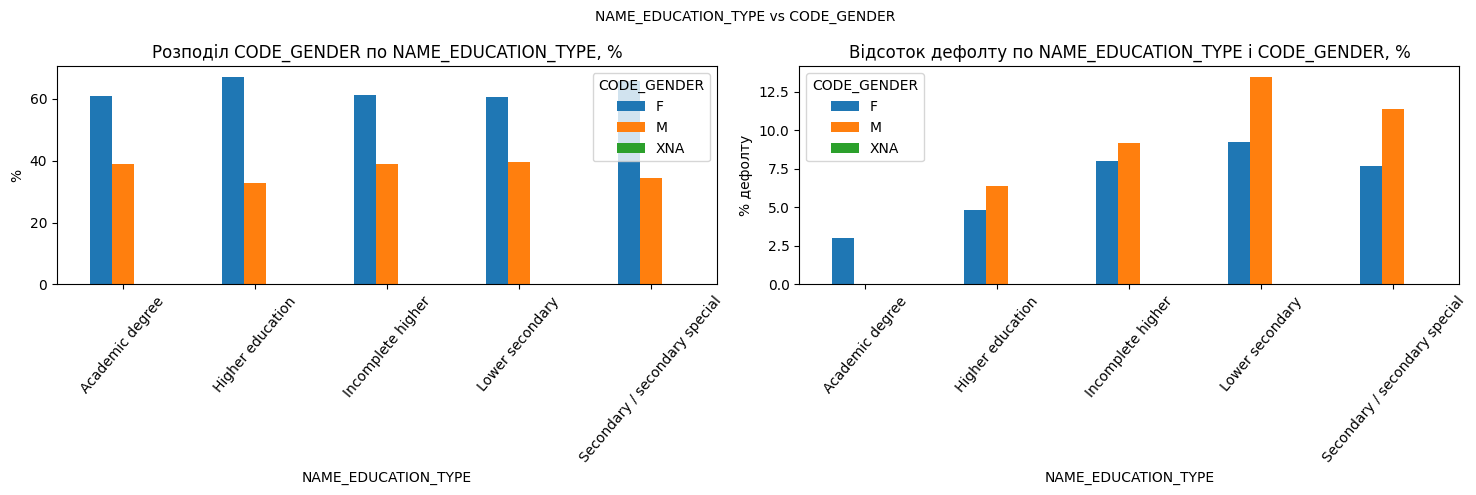

In [92]:
def analyze_cat_cat(cat_col1, cat_col2):
    data = df[[cat_col1, cat_col2, 'TARGET']].dropna()

    print(f'{cat_col1} vs {cat_col2}')
    print(data.groupby([cat_col1, cat_col2])['TARGET'].mean().round(4) * 100)

    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f'{cat_col1} vs {cat_col2}', fontsize=10)

    ct = pd.crosstab(data[cat_col1], data[cat_col2], normalize='index') * 100
    ct.plot(kind='bar', ax=axes[0])
    axes[0].set_title(f'Розподіл {cat_col2} по {cat_col1}, %')
    axes[0].set_xlabel(cat_col1)
    axes[0].set_ylabel('%')
    axes[0].tick_params(axis='x', rotation=50)
    axes[0].legend(title=cat_col2)

    target_rate = data.groupby([cat_col1, cat_col2])['TARGET'].mean() * 100
    target_rate.unstack().plot(kind='bar', ax=axes[1])
    axes[1].set_title(f'Відсоток дефолту по {cat_col1} і {cat_col2}, %')
    axes[1].set_xlabel(cat_col1)
    axes[1].set_ylabel('% дефолту')
    axes[1].tick_params(axis='x', rotation=50)
    axes[1].legend(title=cat_col2)

    plt.tight_layout()
    plt.show()

analyze_cat_cat('NAME_EDUCATION_TYPE', 'CODE_GENDER')

- жінки мають набагато кращу освіту, аніж чоловіки
- люди з lower secondary мають найвищу відсоток дефолту
- чоловіки мають вищий рівень дефолту

ДЗ 9. Висновок з проведеного аналізу
Напишіть Ваш висновок з проведеного ананлізу, яким категоріям осіб Ви б видали кредит? Категорія може бути, наприклад, люди з такою-то освітою, з таким-то доходом, з таким-то досвідом роботи.

Висновок:
На основі аналізу можна зробити висновок, що ідеальним критерієм для видачі кредиту повинні бути клієнти з наступними характеристиками:
- жінка від 35 років
- одружена
- стаж роботи понад 3 роки
- дохід більше 150 тис